# NYC Taxi - Data Overview

This notebook explores the NYC taxi time-series dataset as an operational business time series.
Goals:
- Understand structure (columns, time index, frequency).
- Check data quality (missing values, duplicates).
- Get a first feel for patterns and rare events.


## Load nyc_taxi dataset from NAB data folder

In [5]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
import os

# Path to Numeta Anomoly Benchmark (NAB) data folder
base_path = "../data/NAB-master/data/realKnownCause/"

# Load one example file
file_path = os.path.join(base_path, "nyc_taxi.csv")
df = pd.read_csv(file_path)

df.head()


,timestamp,value
0,2014-07-01 00:00:00,10844
1,2014-07-01 00:30:00,8127
2,2014-07-01 01:00:00,6210
3,2014-07-01 01:30:00,4656
4,2014-07-01 02:00:00,3820


## Basic structure: Shape and Data Types

In [7]:
# Basic structure: how big is the dataset and what are the column types?
df_shape = df.shape
df_info = df.info()

df_shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10320 entries, 0 to 10319
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   timestamp  10320 non-null  object
 1   value      10320 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 161.4+ KB


(10320, 2)

## Time index and sampling frequency

In [11]:
# Convert timestamp column to proper datetime and sort by time
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

# Quick check: start and end of the time series
time_start = df["timestamp"].min()
time_end = df["timestamp"].max()

# Time coverage, start to end
time_start, time_end

(Timestamp('2014-07-01 00:00:00'), Timestamp('2015-01-31 23:30:00'))

## Time index and sampling frequency

In [17]:
# Is the timestamp sorted in time?
is_sorted_by_time = df["timestamp"].is_monotonic_increasing

print("Is timestamp sorted in increasing order?:", is_sorted_by_time)

# What are the most common time gaps?
time_gap_counts = (
    df["timestamp"]
    .diff()
    .value_counts()
    .reset_index()
)

time_gap_counts.columns = ["time_gap", "count"]
time_gap_counts.head()



Is timestamp sorted in increasing order?: True


,time_gap,count
0,0 days 00:30:00,10319


### Time index and sampling frequency key points

- The timestamps move forward in time with no jumps backwards, so the series is in correct time order.
- The gap between almost all timestamps is 30 minutes.
- This means the data is recorded at a regular half-hourly frequency.
- Because the timing is clean and regular, we can use it directly for time-series modelling and anomaly detection without extra resampling for now.


## Data Quality Checks: Missing Values and Duplicates

In [31]:
# Check for missing values in each column
missing_value_summary = (
    df.isna()        # True where values are missing
      .sum()         # count missing values per column
      .reset_index() # turn Series into a small 2-column table
)

missing_value_summary.columns = ["column_name", "missing_count"]
missing_value_summary

,column_name,missing_count
0,timestamp,0
1,value,0


In [35]:
# Check for duplicated timestamps
duplicate_timestamp_count = df["timestamp"].duplicated().sum()
print("\nNumber of duplicated timestamps:", duplicate_timestamp_count)


Number of duplicated timestamps: 0


## Distributions and First Summary Statistics

In [39]:
# Summary statistics for the taxi demand values
value_summary_stats = (
    df["value"]
      .describe()                       # count, mean, std, min, 25%, 50%, 75%, max
      .rename(index={
          "25%": "Q1 (25%)",
          "50%": "Median (50%)",
          "75%": "Q3 (75%)"
      })                                
      .reset_index()
)

value_summary_stats.columns = ["statistic", "value"]
value_summary_stats


,statistic,value
0,count,10320.000000
1,mean,15137.569380
2,std,6939.495808
3,min,8.000000
4,Q1 (25%),10262.000000
5,Median (50%),16778.000000
6,Q3 (75%),19838.750000
7,max,39197.000000


### Summary statistics Interpretation

- The dataset has **10 320 rows**, which is a good amount of data for a case study.
- The time window (July 2014 to end of January 2015) is long enough to cover weekdays, weekends, and several seasonal events.
- The **average demand** is about **15 100 trips**, and the **median** is about **16 800 trips**.
- The median is higher than the mean, which suggests there are some **very low demand periods** that pull the average down.
- The middle 50% of values (between **Q1 ≈ 10 300** and **Q3 ≈ 19 800**) already cover a wide range, so **normal demand is quite variable**.
- The **standard deviation** is about **6 900**, which also shows that the data is spread out and not tightly clustered.
- The **minimum** value is **8 trips**, and the **maximum** is about **39 200 trips**, so the series contains **extreme lows and highs**.
- These patterns suggest that simple fixed thresholds will struggle, and more flexible anomaly detection methods are better suited for this dataset.


## Visual overview: full-series line plot

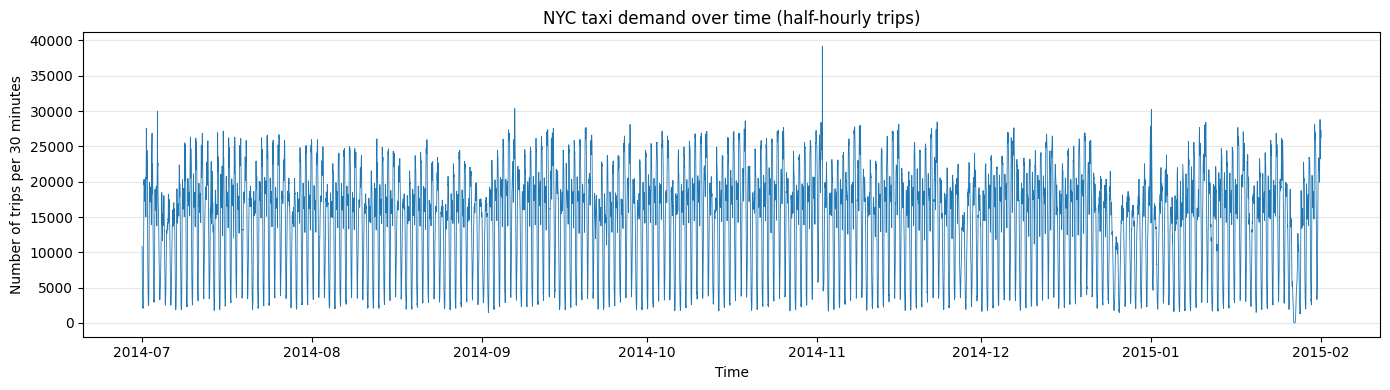

In [41]:
plt.figure(figsize=(14, 4))

# Thinner line so the dense series is easier to read
plt.plot(df["timestamp"], df["value"], linewidth=0.6)

plt.title("NYC taxi demand over time (half-hourly trips)")
plt.xlabel("Time")
plt.ylabel("Number of trips per 30 minutes")

# Light grid 
plt.grid(True, axis="y", alpha=0.3)

plt.tight_layout()


### Visual overview key points

- The series shows a clear repeating up-and-down pattern, which looks like daily and weekly cycles in taxi demand.
- There are regular periods of low demand and high demand, suggesting strong time-of-day and day-of-week effects.
- A few very tall spikes stand out from the rest of the pattern, which are likely linked to special events or disruptions.
- Overall, the plot confirms that NYC taxi demand is dynamic and noisy, not flat, which makes it a good test case for anomaly detection.


## Value distribution: Histogram of Taxi Demand

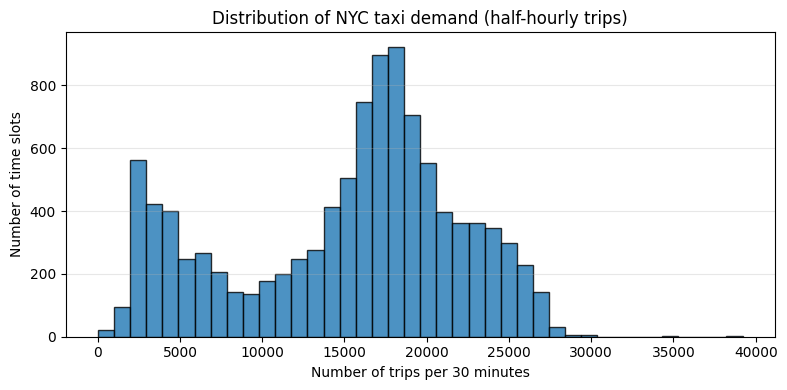

In [46]:
plt.figure(figsize=(8, 4))

# Histogram of demand values
plt.hist(
    df["value"],
    bins=40,
    edgecolor="black",   # clearer bar boundaries
    alpha=0.8            # slightly transparent so overlaps stay readable
)

plt.title("Distribution of NYC taxi demand (half-hourly trips)")
plt.xlabel("Number of trips per 30 minutes")
plt.ylabel("Number of time slots")
plt.grid(axis="y", alpha=0.3)  # horizontal grid for the eye

plt.tight_layout()


### Value distribution key points

- Most half-hour periods fall in the range of roughly **10 000 to 22 000 trips**, which matches the wide middle range seen in the summary statistics.
- There is a smaller cluster of **low-demand periods** (around a few thousand trips), which likely correspond to late-night or very quiet times.
- The right-hand side stretches out towards **very high values** (above 30 000 trips) but these are rare, suggesting occasional extreme peaks.
- Overall, the histogram confirms that normal taxi demand has a **broad spread** with both low and high activity levels, and a few extreme values that could be linked to special events or disruptions.


## Anomaly information: loading NAB labels for NYC taxi

In [62]:
import json  # to work with JSON files

# Tell Python where the labels file is
label_path = "../data/NAB-master/labels/combined_labels.json"

# Open the file and read its contents
with open(label_path, "r") as label_file:      # "r" = read mode, label_file = name for the opened file
    labels = json.load(label_file)             # turn the JSON into a Python dictionary called 'labels'

# Shows the first 10 dataset keys names to confirm it loaded correctly
list(labels.keys())[:10]



['artificialNoAnomaly/art_daily_no_noise.csv',
 'artificialNoAnomaly/art_daily_perfect_square_wave.csv',
 'artificialNoAnomaly/art_daily_small_noise.csv',
 'artificialNoAnomaly/art_flatline.csv',
 'artificialNoAnomaly/art_noisy.csv',
 'artificialWithAnomaly/art_daily_flatmiddle.csv',
 'artificialWithAnomaly/art_daily_jumpsdown.csv',
 'artificialWithAnomaly/art_daily_jumpsup.csv',
 'artificialWithAnomaly/art_daily_nojump.csv',
 'artificialWithAnomaly/art_increase_spike_density.csv']

In [58]:
# Pick out the labels for the NYC taxi dataset
nyc_taxi_key = "realKnownCause/nyc_taxi.csv"

nyc_taxi_label_strings = labels[nyc_taxi_key]

# Turn the list of timestamp strings into a DataFrame
nyc_taxi_labels_df = pd.DataFrame(
    {"timestamp": pd.to_datetime(nyc_taxi_label_strings)}
)

nyc_taxi_labels_df.head()

,timestamp
0,2014-11-01 19:00:00
1,2014-11-27 15:30:00
2,2014-12-25 15:00:00
3,2015-01-01 01:00:00
4,2015-01-27 00:00:00


In [63]:
print(f"\nNumber of anomalies: {len(nyc_taxi_labels_df)}")


Number of anomalies: 5


## Anomaly information: Labelled events

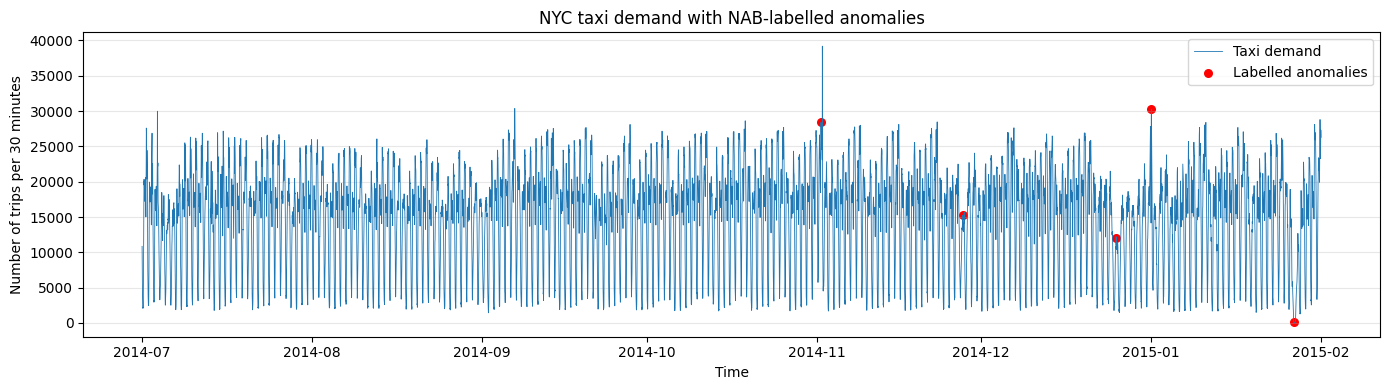

In [61]:
plt.figure(figsize=(14, 4))

# Full NYC taxi series
plt.plot(df["timestamp"], df["value"], linewidth=0.6, label="Taxi demand")

# Overlay labelled anomaly points
plt.scatter(
    nyc_taxi_labels_df["timestamp"],
    df.set_index("timestamp").loc[nyc_taxi_labels_df["timestamp"], "value"],
    color="red",
    s=30,
    label="Labelled anomalies"
)

plt.title("NYC taxi demand with NAB-labelled anomalies")
plt.xlabel("Time")
plt.ylabel("Number of trips per 30 minutes")
plt.grid(axis="y", alpha=0.3)
plt.legend()

plt.tight_layout()


### Labelled anomalies key points

- The NAB benchmark marks **5 specific timestamps** in the NYC taxi series as anomalies.
- These points sit on top of otherwise regular daily and weekly patterns, and appear as strong peaks or unusual changes.
- Compared to more than **10 000** normal time steps, the anomalies are very rare, which creates a clear class imbalance between normal and abnormal behaviour.
- In the later results chapter, these labelled events will act as ground truth for evaluating how well different anomaly detection methods, including diffusion-based approaches, can pick up rare but impactful changes in demand.


## Local pattern: zoom into a typical week

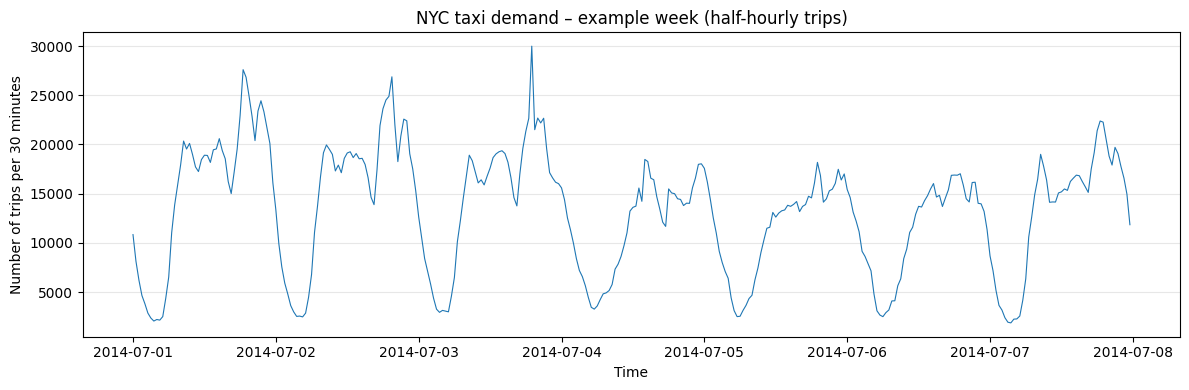

In [65]:
# Define the start and end of the week we want to zoom into
week_start = pd.Timestamp("2014-07-01")
week_end = pd.Timestamp("2014-07-08")

# Keep only rows where the timestamp falls inside this week
one_week = df[(df["timestamp"] >= week_start) & (df["timestamp"] < week_end)]

# Plot taxi demand for this one-week window
plt.figure(figsize=(12, 4))
plt.plot(one_week["timestamp"], one_week["value"], linewidth=0.8)

plt.title("NYC taxi demand – example week (half-hourly trips)")
plt.xlabel("Time")
plt.ylabel("Number of trips per 30 minutes")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()


### Example week key points

- The line moves up and down in a regular wave each day, showing clear daily cycles in demand.
- Low points likely correspond to late-night or early-morning periods with fewer riders.
- High points line up with busy daytime and evening periods.
- Some days look busier than others, which hints at weekday–weekend differences.
- This daily and weekly structure is part of what our anomaly detection methods need to understand as “normal” background behaviour.


## Class balance: normal vs labelled anomalies

In [66]:
# Mark each timestamp as anomaly (1) or normal (0)
df_with_labels = df.copy()

# True where the timestamp is in the anomaly list, False otherwise
df_with_labels["is_anomaly"] = df_with_labels["timestamp"].isin(
    nyc_taxi_labels_df["timestamp"]
)

# Turn True/False into 1/0 for later modelling
df_with_labels["is_anomaly"] = df_with_labels["is_anomaly"].astype(int)

# Count how many normal vs anomalous points we have
class_counts = (
    df_with_labels["is_anomaly"]
      .value_counts()
      .rename(index={0: "normal", 1: "anomaly"})
      .reset_index()
)

class_counts.columns = ["class", "count"]
class_counts


,class,count
0,normal,10315
1,anomaly,5


### Class balance key points

- The table shows how many points are labelled as **normal** and how many as **anomalies**.
- There are only a **handful of anomaly points** compared to more than **10 000 normal points**, so the dataset is highly imbalanced.
- This mirrors real business settings, where unusual events are rare, and supports treating anomaly detection as a rare-event detection problem.
- Later, this imbalance will influence how we design evaluation metrics and baselines, because simple accuracy alone would be misleading.


## Notes for preprocessing and modelling


### NYC taxi – preprocessing and modelling notes

- **Time handling**
  - Timestamps are already clean, strictly increasing, and on a regular 30-minute grid.
  - We probably do **not** need resampling for this dataset; we can keep the native half-hour frequency.

- **Missing data and duplicates**
  - There are no missing values and no duplicated timestamps.
  - Preprocessing for this dataset will mainly focus on **standardisation**, not heavy cleaning.

- **Value range and scaling**
  - Values range from **8** to about **39 200** trips per 30 minutes, with a wide “normal” band between roughly **10k and 20k**.
  - For many models (including diffusion approaches), it will be useful to **scale or normalise** the `value` column (for example, by standardisation or min–max scaling) so that training is stable.

- **Seasonality and trends**
  - There are strong **daily and weekly cycles** in demand.
  - Any model or baseline should respect this structure (for example, by using sliding windows that cover several days, or features that encode time-of-day and day-of-week).

- **Anomaly labels and imbalance**
  - NAB provides **5 labelled anomaly timestamps** for this series, compared to more than **10 000 normal points**.
  - This strong class imbalance means that later evaluation must go beyond simple accuracy and use metrics that are sensitive to rare events (e.g. precision/recall on anomaly windows).

- **Case study role in the thesis**
  - NYC taxi acts as a **dynamic demand case study**, complementing the ambient temperature failure case.
  - It will help show how diffusion-based anomaly detection behaves in a noisy, event-driven business time series with rare but important spikes and dips.
